# Association Rule Mining using Apriori and FP-Growth

## Objective

The objective of this notebook is to perform Association Rule Mining on the Groceries Market Basket Dataset using Apriori and FP-Growth algorithms. The notebook compares both algorithms based on frequent itemsets, association rules, execution time, and rule quality using support, confidence, and lift.

## Step 1: Import Required Libraries



In [1]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

import time

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load the Groceries Dataset



In [2]:


df = pd.read_csv("Groceries_dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


## Step 3: Explore the Dataset Structure



In [3]:


# Display first five rows
display(df.head())

# Dataset dimensions
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Dataset information
print("\nDataset Information:")
df.info()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


Dataset Shape: (38765, 3)

Columns:
['Member_number', 'Date', 'itemDescription']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Member_number    38765 non-null  int64
 1   Date             38765 non-null  str  
 2   itemDescription  38765 non-null  str  
dtypes: int64(1), str(2)
memory usage: 908.7 KB

Missing Values:
Member_number      0
Date               0
itemDescription    0
dtype: int64


# Group purchased items into transactions


In [15]:

transactions = (
    df.groupby(["Member_number", "Date"])["itemDescription"]
      .apply(list)
      .tolist()
)

print("Total Transactions:", len(transactions))

print("\nFirst 5 Transactions:")

for t in transactions[:5]:
    print(t)



Total Transactions: 14963

First 5 Transactions:
['sausage', 'whole milk', 'semi-finished bread', 'yogurt']
['whole milk', 'pastry', 'salty snack']
['canned beer', 'misc. beverages']
['sausage', 'hygiene articles']
['soda', 'pickled vegetables']


## Step 4: Convert Transactions into One-Hot Encoded Format



In [16]:
te = TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)

df_encoded = pd.DataFrame(
    te_array,
    columns=te.columns_
)

print("Encoded Dataset Shape:", df_encoded.shape)

display(df_encoded.head())

Encoded Dataset Shape: (14963, 167)


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Step 5: Generate Frequent Itemsets using the Apriori Algorithm



In [17]:
min_support = 0.01

frequent_itemsets = apriori(
    df_encoded,
    min_support=min_support,
    use_colnames=True
)

frequent_itemsets["Length"] = frequent_itemsets["itemsets"].apply(len)

print("Minimum Support:", min_support)
print("Total Frequent Itemsets:", len(frequent_itemsets))

print("\nLength Distribution:")
print(frequent_itemsets["Length"].value_counts())

display(frequent_itemsets)

Minimum Support: 0.01
Total Frequent Itemsets: 69

Length Distribution:
Length
1    64
2     5
Name: count, dtype: int64


,support,itemsets,Length
0,0.021386,frozenset({UHT-milk}),1
1,0.033950,frozenset({beef}),1
2,0.021787,frozenset({berries}),1
3,0.016574,frozenset({beverages}),1
4,0.045312,frozenset({bottled beer}),1
...,...,...,...
64,0.010559,"frozenset({rolls/buns, other vegetables})",2
65,0.014837,"frozenset({whole milk, other vegetables})",2
66,0.013968,"frozenset({whole milk, rolls/buns})",2
67,0.011629,"frozenset({whole milk, soda})",2


## Step 6: Generate Association Rules

In [18]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.10
)

print("Total Association Rules:", len(rules))

rules = rules.sort_values(by="lift", ascending=False)

display(
    rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(10)
)

Total Association Rules: 4


,antecedents,consequents,support,confidence,lift
3,frozenset({yogurt}),frozenset({whole milk}),0.011161,0.129961,0.822940
1,frozenset({rolls/buns}),frozenset({whole milk}),0.013968,0.126974,0.804028
0,frozenset({other vegetables}),frozenset({whole milk}),0.014837,0.121511,0.769430
2,frozenset({soda}),frozenset({whole milk}),0.011629,0.119752,0.758296


## FP-Growth

In [19]:
fp_itemsets = fpgrowth(
    df_encoded,
    min_support=0.01,
    use_colnames=True
)

fp_itemsets["Length"] = fp_itemsets["itemsets"].apply(len)

print("Total FP-Growth Itemsets:", len(fp_itemsets))

display(fp_itemsets.head(10))

Total FP-Growth Itemsets: 69


,support,itemsets,Length
0,0.157923,frozenset({whole milk}),1
1,0.085879,frozenset({yogurt}),1
2,0.060349,frozenset({sausage}),1
3,0.051728,frozenset({pastry}),1
4,0.018780,frozenset({salty snack}),1
5,0.046916,frozenset({canned beer}),1
6,0.015772,frozenset({misc. beverages}),1
7,0.013700,frozenset({hygiene articles}),1
8,0.097106,frozenset({soda}),1
9,0.037760,frozenset({frankfurter}),1


 ## FP-Growth Rules

In [20]:
fp_rules = association_rules(
    fp_itemsets,
    metric="confidence",
    min_threshold=0.10
)

print("Total FP-Growth Rules:", len(fp_rules))

display(
    fp_rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(10)
)

Total FP-Growth Rules: 4


,antecedents,consequents,support,confidence,lift
0,frozenset({yogurt}),frozenset({whole milk}),0.011161,0.129961,0.822940
1,frozenset({soda}),frozenset({whole milk}),0.011629,0.119752,0.758296
2,frozenset({rolls/buns}),frozenset({whole milk}),0.013968,0.126974,0.804028
3,frozenset({other vegetables}),frozenset({whole milk}),0.014837,0.121511,0.769430


## Runtime Comparison

In [21]:
import time

start = time.time()
apriori(df_encoded, min_support=0.01, use_colnames=True)
apriori_time = time.time() - start

start = time.time()
fpgrowth(df_encoded, min_support=0.01, use_colnames=True)
fpgrowth_time = time.time() - start

runtime_df = pd.DataFrame({
    "Algorithm": ["Apriori", "FP-Growth"],
    "Execution Time (Seconds)": [apriori_time, fpgrowth_time]
})

display(runtime_df)

,Algorithm,Execution Time (Seconds)
0,Apriori,0.193018
1,FP-Growth,0.130778


## Different Support Values

In [22]:
supports = [0.01, 0.02, 0.05]

comparison = []

for s in supports:
    itemsets = apriori(df_encoded, min_support=s, use_colnames=True)

    rules = association_rules(
        itemsets,
        metric="confidence",
        min_threshold=0.10
    )

    comparison.append([
        s,
        len(itemsets),
        len(rules)
    ])

comparison_df = pd.DataFrame(
    comparison,
    columns=[
        "Min Support",
        "Frequent Itemsets",
        "Association Rules"
    ]
)

display(comparison_df)

,Min Support,Frequent Itemsets,Association Rules
0,0.01,69,4
1,0.02,38,0
2,0.05,11,0


In [24]:
confidence_values = [0.3, 0.5, 0.7]

confidence_results = []

for c in confidence_values:
    rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=c
    )

    confidence_results.append({
        "Min Confidence": c,
        "Association Rules": len(rules)
    })

confidence_df = pd.DataFrame(confidence_results)

display(confidence_df)

,Min Confidence,Association Rules
0,0.3,0
1,0.5,0
2,0.7,0


## Top 10 Rules by Lift

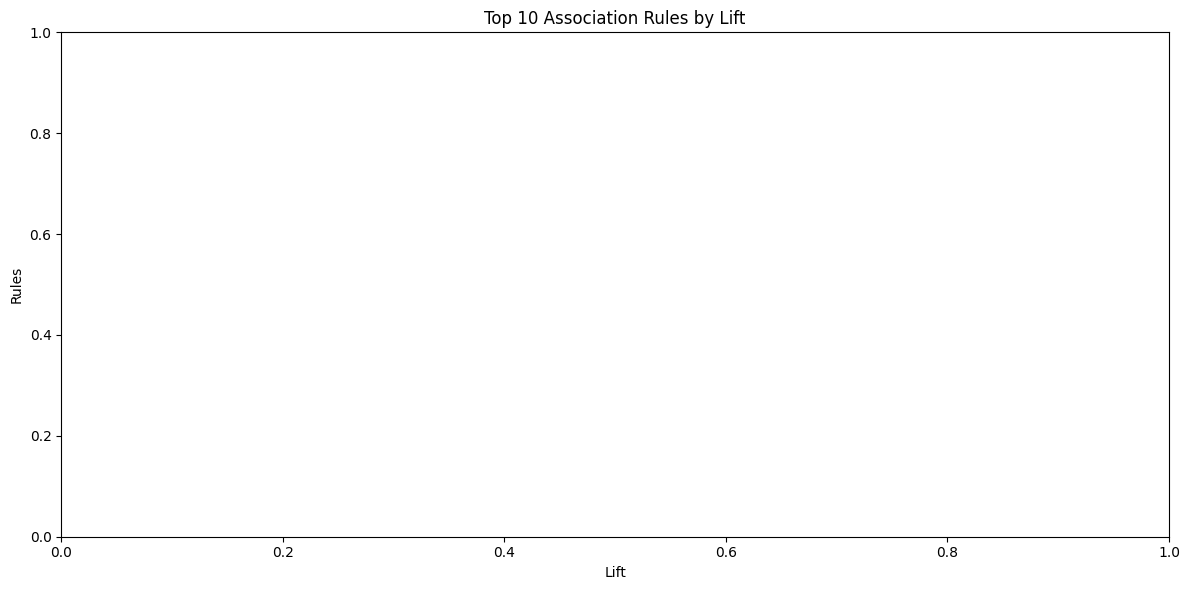

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

top_rules = rules.sort_values(
    by="lift",
    ascending=False
).head(10)

top_rules["Rule"] = (
    top_rules["antecedents"].astype(str)
    + " → "
    + top_rules["consequents"].astype(str)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_rules,
    x="lift",
    y="Rule"
)

plt.title("Top 10 Association Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Rules")

plt.tight_layout()
plt.show()

# Rule Mining Summary

The Groceries Market Basket dataset was analyzed using both Apriori and FP-Growth algorithms to discover frequent itemsets and association rules.

A minimum support value of 0.01 was selected to capture meaningful purchasing patterns while retaining a sufficient number of frequent itemsets. This resulted in 69 frequent itemsets, whereas higher support values (0.02 and 0.05) produced fewer itemsets and no association rules.

The strongest rules indicated that customers purchasing products such as yogurt, rolls/buns, soda, and other vegetables also tended to purchase whole milk. However, the lift values were below 1, indicating weak positive associations rather than strong purchasing relationships.

FP-Growth produced the same frequent itemsets and association rules as Apriori but completed the task in less execution time. This demonstrates that FP-Growth is more efficient because it uses a compressed FP-Tree structure instead of repeatedly generating candidate itemsets like Apriori.

For larger real-world retail datasets, FP-Growth would be the preferred algorithm due to its faster execution and better scalability while maintaining the same analytical results.